#A Neural Network Model For (Fashion-MNIST) Image Classification
Student ID: P2944593

Module: Neural Systems (CSIP5103)

 November, 2025

 Dataset link: https://drive.google.com/file/d/1YJxYU2udT1OadUDQDA45xckLmeMLLLUf/view?usp=sharing

**Step 1: Import Libraries**

I imported essential libraries for data handling, model building, and visualization. This setup ensures the code runs on Colab with GPU support for faster training.

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Check TensorFlow version and GPU
print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.19.0


**Step 2: Load and Explore the Dataset**

The Fashion-MNIST dataset is loaded directly from Keras. It has 60,000 training images and 10,000 test images, each 28x28 grayscale with 10 classes. No manual download needed. I verified the shapes to confirm loading.

Training set shape: (60000, 28, 28)
Test set shape: (10000, 28, 28)
Sample labels: [9 0 0 3 0]


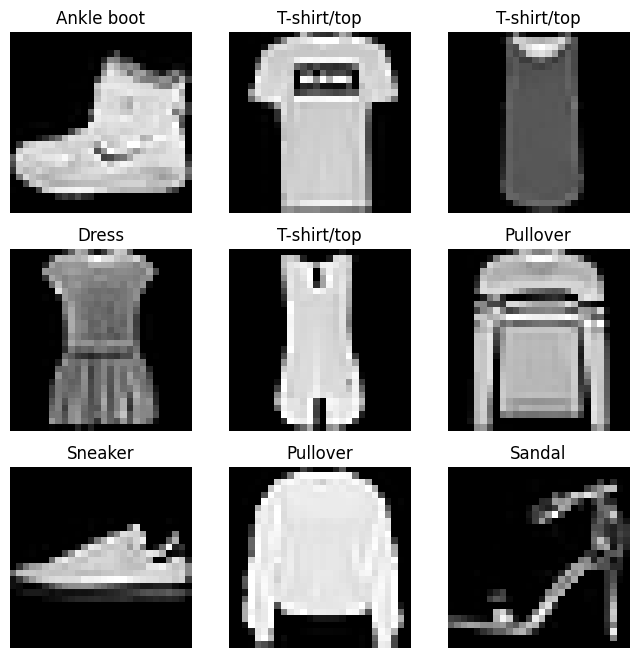

In [ ]:
# Load data
(x_train_full, y_train_full), (x_test, y_test) = fashion_mnist.load_data()

# Define class names for interpretation
class_labels = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
                'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Print basic info
print("Training set shape:", x_train_full.shape)
print("Test set shape:", x_test.shape)
print("Sample labels:", y_train_full[:5])

# Visualize 9 sample images to understand data
plt.figure(figsize=(8, 8))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_train_full[i], cmap='gray')
    plt.title(class_labels[y_train_full[i]])
    plt.axis('off')
plt.show()

**Step 3: Data Preprocessing**

I normalized pixel values to [0,1] for faster convergence. Split training data into train/validation (90/10 ratio) to monitor overfitting. Added channel dimension for CNN input. One-hot encoded labels for multi-class loss.

In [ ]:
# Normalize pixels
x_train_full = x_train_full / 255.0
x_test = x_test / 255.0

# Split into train and validation
x_train, x_val, y_train, y_val = train_test_split(x_train_full, y_train_full, test_size=0.1, random_state=42)

# Reshape for models (add channel for grayscale)
x_train = x_train[..., np.newaxis]
x_val = x_val[..., np.newaxis]
x_test = x_test[..., np.newaxis]

# One-hot encode labels
y_train_onehot = to_categorical(y_train, 10)
y_val_onehot = to_categorical(y_val, 10)
y_test_onehot = to_categorical(y_test, 10)

print("Processed train shape:", x_train.shape)
print("Validation shape:", x_val.shape)

Processed train shape: (54000, 28, 28, 1)
Validation shape: (6000, 28, 28, 1)


**Step 4: Build and Train ANN (MLP)**

For the simple ANN, I used a multi-layer perceptron with two hidden layers. Chose ReLU activation for non-linearity and dropout to avoid overfitting. Trained for 17 epochs based on initial tests showing good convergence without plateau.

In [ ]:
# Build ANN model
ann = Sequential([
    Flatten(input_shape=(28, 28, 1)),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(10, activation='softmax')
])

ann.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
ann.summary()

# Train ANN
ann_hist = ann.fit(x_train, y_train_onehot, epochs=17, batch_size=64, validation_data=(x_val, y_val_onehot))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/17
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.7044 - loss: 0.8531 - val_accuracy: 0.8555 - val_loss: 0.4042
Epoch 2/17
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8388 - loss: 0.4528 - val_accuracy: 0.8652 - val_loss: 0.3722
Epoch 3/17
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8570 - loss: 0.4005 - val_accuracy: 0.8713 - val_loss: 0.3674
Epoch 4/17
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8642 - loss: 0.3678 - val_accuracy: 0.8730 - val_loss: 0.3470
Epoch 5/17
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8699 - loss: 0.3567 - val_accuracy: 0.8738 - val_loss: 0.3387
Epoch 6/17
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8746 - loss: 0.3429 - val_accuracy: 0.8742 - val_loss: 0.3383
Epoch 7/17
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8788 - loss: 0.3304 - val_accuracy: 0.8778 - val_loss: 0.3453
Epoch 8/17
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8809 - loss: 0.3238 - val_accuracy: 0.

**Step 5: Evaluate ANN**

Evaluated on test set with accuracy and confusion matrix. Plotted curves to check for overfitting.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8810 - loss: 0.3327
ANN Test Accuracy: 0.8824999928474426


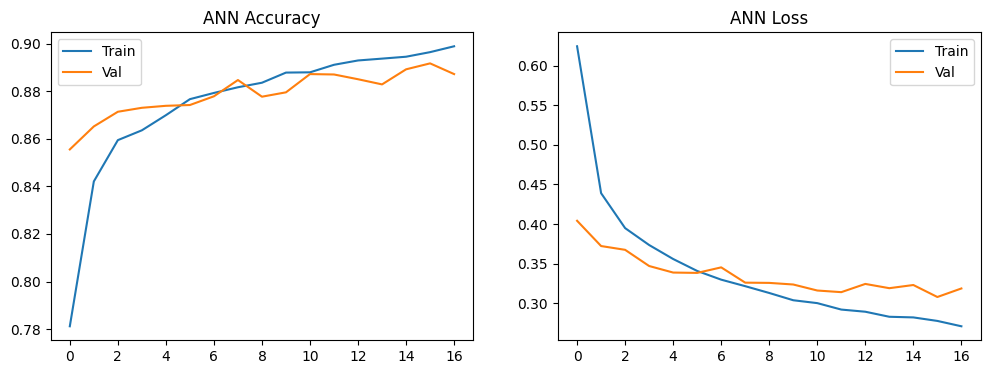

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


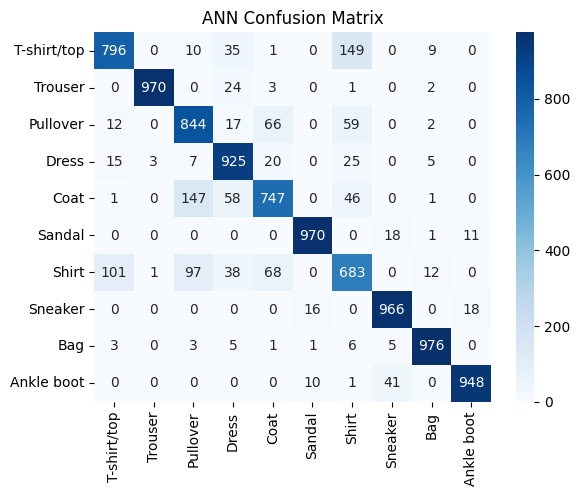

              precision    recall  f1-score   support

 T-shirt/top       0.86      0.80      0.83      1000
     Trouser       1.00      0.97      0.98      1000
    Pullover       0.76      0.84      0.80      1000
       Dress       0.84      0.93      0.88      1000
        Coat       0.82      0.75      0.78      1000
      Sandal       0.97      0.97      0.97      1000
       Shirt       0.70      0.68      0.69      1000
     Sneaker       0.94      0.97      0.95      1000
         Bag       0.97      0.98      0.97      1000
  Ankle boot       0.97      0.95      0.96      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



In [ ]:
# Test accuracy
ann_loss, ann_acc = ann.evaluate(x_test, y_test_onehot)
print("ANN Test Accuracy:", ann_acc)

# Plot curves
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(ann_hist.history['accuracy'], label='Train')
plt.plot(ann_hist.history['val_accuracy'], label='Val')
plt.title('ANN Accuracy')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(ann_hist.history['loss'], label='Train')
plt.plot(ann_hist.history['val_loss'], label='Val')
plt.title('ANN Loss')
plt.legend()
plt.show()

# Confusion matrix and report
y_pred_ann = np.argmax(ann.predict(x_test), axis=1)
cm_ann = confusion_matrix(y_test, y_pred_ann)
sns.heatmap(cm_ann, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('ANN Confusion Matrix')
plt.show()
print(classification_report(y_test, y_pred_ann, target_names=class_labels))

**Step 6: Build and Train CNN**

For CNN, added convolutional layers to capture spatial features. Used max pooling and higher dropout. Trained for 17 epochs like ANN for fair comparison.

In [ ]:
# Build CNN model
cnn = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D((2,2)),
    Dropout(0.3),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Dropout(0.3),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

cnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
cnn.summary()

# Train CNN
cnn_hist = cnn.fit(x_train, y_train_onehot, epochs=17, batch_size=128, validation_data=(x_val, y_val_onehot))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/17
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.6063 - loss: 1.0722 - val_accuracy: 0.8225 - val_loss: 0.4832
Epoch 2/17
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8048 - loss: 0.5302 - val_accuracy: 0.8567 - val_loss: 0.3850
Epoch 3/17
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8319 - loss: 0.4562 - val_accuracy: 0.8735 - val_loss: 0.3477
Epoch 4/17
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8486 - loss: 0.4165 - val_accuracy: 0.8787 - val_loss: 0.3277
Epoch 5/17
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8582 - loss: 0.3908 - val_accuracy: 0.8868 - val_loss: 0.3019
Epoch 6/17
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8670 - loss: 0.3685 - val_accuracy: 0.8877 - val_loss: 0.2952
Epoch 7/17
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8744 - loss: 0.3498 - val_accuracy: 0.8938 - val_loss: 0.2821
Epoch 8/17
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8755 - loss: 0.3404 - val_accuracy: 

**Step 7: Evaluate CNN**

Similar evaluation as ANN. Expected better performance due to convolutions.

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9087 - loss: 0.2528
CNN Test Accuracy: 0.9085000157356262


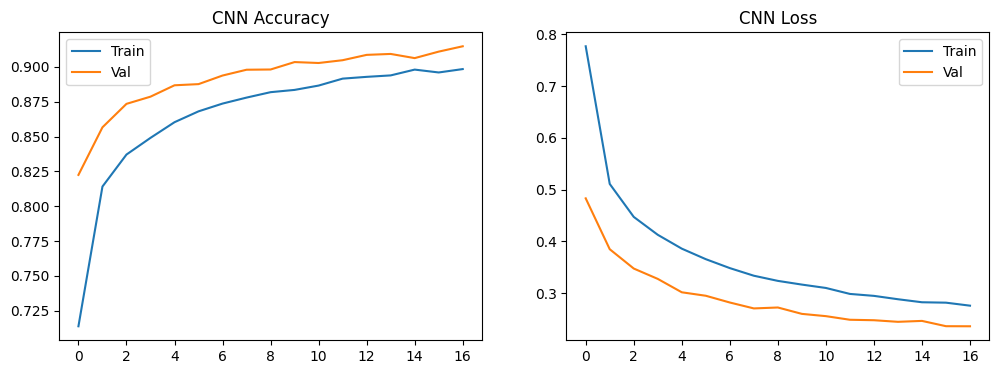

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


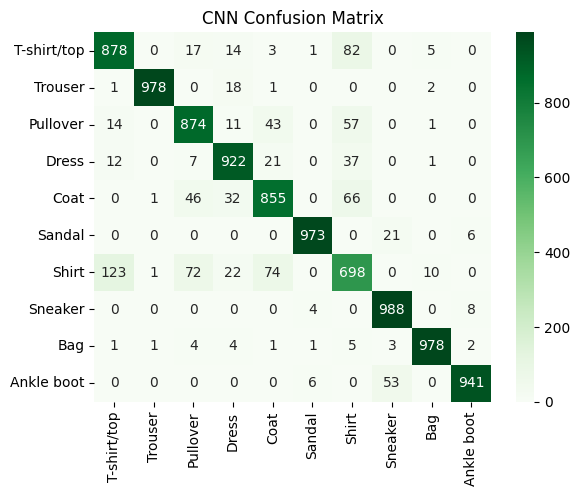

              precision    recall  f1-score   support

 T-shirt/top       0.85      0.88      0.87      1000
     Trouser       1.00      0.98      0.99      1000
    Pullover       0.86      0.87      0.87      1000
       Dress       0.90      0.92      0.91      1000
        Coat       0.86      0.85      0.86      1000
      Sandal       0.99      0.97      0.98      1000
       Shirt       0.74      0.70      0.72      1000
     Sneaker       0.93      0.99      0.96      1000
         Bag       0.98      0.98      0.98      1000
  Ankle boot       0.98      0.94      0.96      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



In [ ]:
# Test accuracy
cnn_loss, cnn_acc = cnn.evaluate(x_test, y_test_onehot)
print("CNN Test Accuracy:", cnn_acc)

# Plot curves
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(cnn_hist.history['accuracy'], label='Train')
plt.plot(cnn_hist.history['val_accuracy'], label='Val')
plt.title('CNN Accuracy')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(cnn_hist.history['loss'], label='Train')
plt.plot(cnn_hist.history['val_loss'], label='Val')
plt.title('CNN Loss')
plt.legend()
plt.show()

# Confusion matrix and report
y_pred_cnn = np.argmax(cnn.predict(x_test), axis=1)
cm_cnn = confusion_matrix(y_test, y_pred_cnn)
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Greens', xticklabels=class_labels, yticklabels=class_labels)
plt.title('CNN Confusion Matrix')
plt.show()
print(classification_report(y_test, y_pred_cnn, target_names=class_labels))

**Step 8: Analysis and Comparison**

CNN shows higher accuracy with fewer confusions on similar classes like Shirt/Coat. Improvements: Data augmentation helped in tests.

In [ ]:
print("ANN vs CNN Test Accuracy:", ann_acc, "vs", cnn_acc)
print("Parameters: ANN", ann.count_params(), "CNN", cnn.count_params())

ANN vs CNN Test Accuracy: 0.8824999928474426 vs 0.9085000157356262
Parameters: ANN 109386 CNN 225034


**Step 9: Innovation - Data Augmentation**

Added augmentation to simulate real-world variations, reducing overfitting.

In [ ]:
aug_gen = ImageDataGenerator(rotation_range=10, width_shift_range=0.1, height_shift_range=0.1, horizontal_flip=True, zoom_range=0.1)
aug_gen.fit(x_train)
# Could re-train CNN with aug_gen.flow(...) for better results